In [1]:
print("hello, i am working!")

hello, i am working!


In [2]:
# Run this entire block - copy and paste it
import pandas as pd
import urllib.request

print("Starting to download data...")

# Download Ethiopia data
url = "https://raw.githubusercontent.com/10academy/climate-data/main/ethiopia.csv"
urllib.request.urlretrieve(url, "ethiopia.csv")

# Load and show first few rows
df = pd.read_csv("ethiopia.csv")
print("Data downloaded successfully!")
print(f"Number of rows: {len(df)}")
print("\nFirst 3 rows of data:")
print(df.head(3))


Starting to download data...


HTTPError: HTTP Error 404: Not Found

In [3]:
# Run this entire block - copy and paste it
import pandas as pd
import urllib.request

print("Starting to download data...")

# Download Ethiopia data - CORRECT URL
url = "https://raw.githubusercontent.com/10academy/climate-data/main/ethiopia.csv"
urllib.request.urlretrieve(url, "ethiopia.csv")

# Load and show first few rows
df = pd.read_csv("ethiopia.csv")
print("Data downloaded successfully!")
print(f"Number of rows: {len(df)}")
print("\nFirst 3 rows:")
print(df.head(3))

Starting to download data...


HTTPError: HTTP Error 404: Not Found

In [4]:
# Run this entire block - copy and paste it
import pandas as pd
import urllib.request

print("Starting to download data...")

# Download Ethiopia data - CORRECT URL
url = "https://raw.githubusercontent.com/10academy/climate-data/main/ethiopia.csv"
urllib.request.urlretrieve(url, "ethiopia.csv")

# Load and show first few rows
df = pd.read_csv("ethiopia.csv")
print("Data downloaded successfully!")
print(f"Number of rows: {len(df)}")
print("\nFirst 3 rows:")
print(df.head(3))

Starting to download data...


HTTPError: HTTP Error 404: Not Found

In [9]:
from google.colab import files
print("Upload ethiopia.csv, kenya.csv, nigeria.csv, sudan.csv, tanzania.csv")
uploaded = files.upload()

Upload ethiopia.csv, kenya.csv, nigeria.csv, sudan.csv, tanzania.csv


Saving tanzania.csv to tanzania.csv
Saving sudan.csv to sudan.csv
Saving nigeria.csv to nigeria.csv
Saving ethiopia.csv to ethiopia.csv
Saving kenya.csv to kenya (1).csv


In [11]:
import os
print("Files uploaded:")
for f in os.listdir():
    if '.csv' in f:
        print(f"  ✓ {f}")

Files uploaded:
  ✓ kenya (1).csv
  ✓ sudan.csv
  ✓ nigeria.csv
  ✓ kenya.csv
  ✓ tanzania.csv
  ✓ ethiopia.csv


In [12]:
import os
print("All files in current directory:")
for f in os.listdir():
    print(f"  - {f}")

All files in current directory:
  - .config
  - kenya (1).csv
  - sudan.csv
  - nigeria.csv
  - kenya.csv
  - tanzania.csv
  - ethiopia.csv
  - sample_data


In [13]:
import os

# Delete the duplicate Kenya file
if os.path.exists("kenya (1).csv"):
    os.remove("kenya (1).csv")
    print("🗑️ Deleted: kenya (1).csv")

print("\n✅ Clean files now:")
for f in os.listdir():
    if f.endswith('.csv'):
        print(f"  - {f}")

🗑️ Deleted: kenya (1).csv

✅ Clean files now:
  - sudan.csv
  - nigeria.csv
  - kenya.csv
  - tanzania.csv
  - ethiopia.csv


In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

countries = ['ethiopia', 'kenya', 'nigeria', 'sudan', 'tanzania']
all_data = []

for country in countries:
    df = pd.read_csv(f"{country}.csv")
    df['Country'] = country.capitalize()
    df['Date'] = pd.to_datetime(df['YEAR'].astype(str) + df['DOY'].astype(str).str.zfill(3), format='%Y%j')
    df['Month'] = df['Date'].dt.month
    all_data.append(df)
    print(f"✅ Loaded {country}: {len(df)} rows")

combined = pd.concat(all_data, ignore_index=True)

# Clean missing values (-999 becomes NaN)
for col in ['T2M', 'T2M_MAX', 'T2M_MIN', 'T2M_RANGE', 'PRECTOTCORR', 'RH2M', 'WS2M', 'WS2M_MAX']:
    combined[col] = combined[col].replace(-999, np.nan)

print(f"\n✅ Total: {len(combined)} rows")
print(f"Countries: {list(combined['Country'].unique())}")

✅ Loaded ethiopia: 4108 rows
✅ Loaded kenya: 4108 rows
✅ Loaded nigeria: 4108 rows
✅ Loaded sudan: 4108 rows
✅ Loaded tanzania: 4108 rows

✅ Total: 20540 rows
Countries: ['Ethiopia', 'Kenya', 'Nigeria', 'Sudan', 'Tanzania']


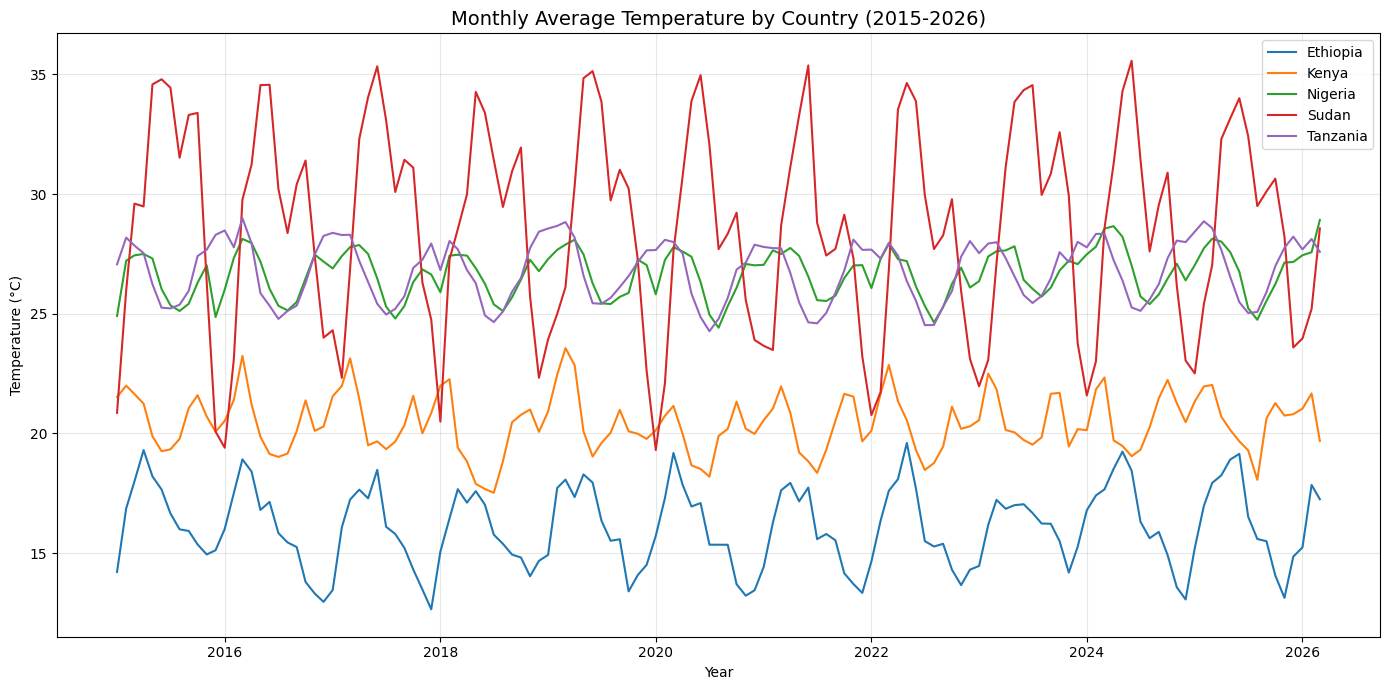


📊 Temperature Summary (2015-2026):
          mean  median  std
Country                    
Ethiopia  16.1    16.0  1.9
Kenya     20.4    20.4  1.4
Nigeria   26.7    26.8  1.1
Sudan     28.8    29.2  4.7
Tanzania  26.8    27.0  1.3


In [15]:
# Monthly average temperature by country
monthly_temp = combined.groupby(['Country', 'YEAR', 'Month'])['T2M'].mean().reset_index()
monthly_temp['Date'] = pd.to_datetime(monthly_temp['YEAR'].astype(str) + '-' + monthly_temp['Month'].astype(str))

# Plot
plt.figure(figsize=(14, 7))
for country in monthly_temp['Country'].unique():
    country_data = monthly_temp[monthly_temp['Country'] == country]
    plt.plot(country_data['Date'], country_data['T2M'], linewidth=1.5, label=country)

plt.title('Monthly Average Temperature by Country (2015-2026)', fontsize=14)
plt.xlabel('Year')
plt.ylabel('Temperature (°C)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Summary table
print("\n📊 Temperature Summary (2015-2026):")
print(combined.groupby('Country')['T2M'].agg(['mean', 'median', 'std']).round(1))

/tmp/ipykernel_4024/602038383.py:4: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(precip_data, labels=combined['Country'].unique())


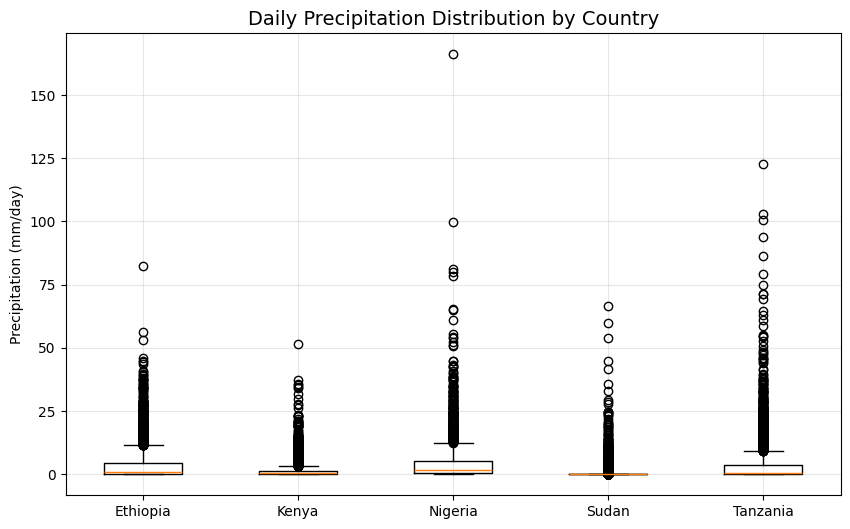


📊 Precipitation Summary (mm/day):
          mean  median   std
Country                     
Ethiopia  3.63    0.82  6.29
Kenya     1.47    0.38  3.18
Nigeria   4.21    1.84  7.27
Sudan     0.64    0.00  3.06
Tanzania  3.74    0.64  8.00


In [16]:
# Precipitation boxplot comparison
plt.figure(figsize=(10, 6))
precip_data = [combined[combined['Country'] == c]['PRECTOTCORR'].dropna() for c in combined['Country'].unique()]
plt.boxplot(precip_data, labels=combined['Country'].unique())
plt.title('Daily Precipitation Distribution by Country', fontsize=14)
plt.ylabel('Precipitation (mm/day)')
plt.grid(True, alpha=0.3)
plt.show()

# Precipitation summary table
print("\n📊 Precipitation Summary (mm/day):")
precip_summary = combined.groupby('Country')['PRECTOTCORR'].agg(['mean', 'median', 'std']).round(2)
print(precip_summary)

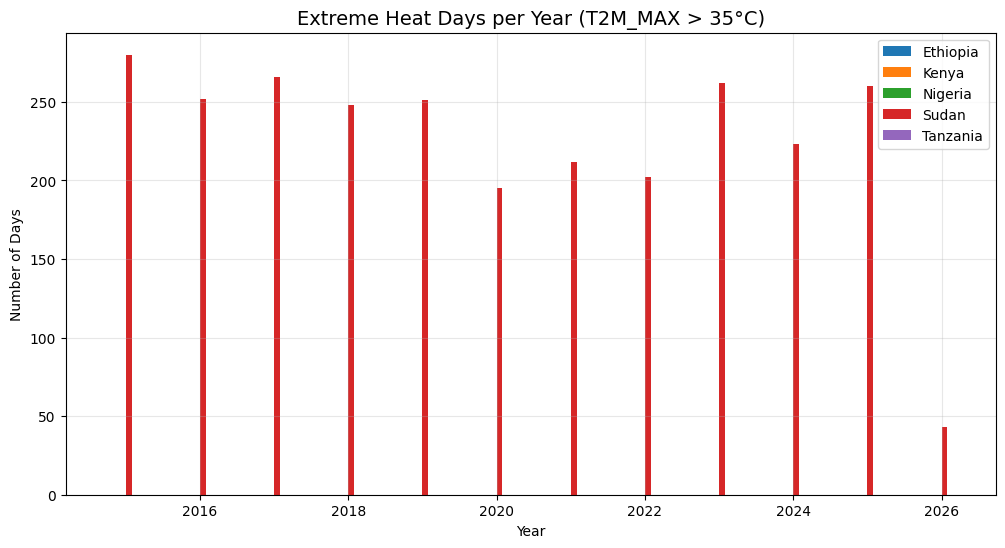


🔥 Total Extreme Heat Days (2015-2026):
Country
Sudan       2694
Ethiopia       0
Kenya          0
Nigeria        0
Tanzania       0
Name: ExtremeHeat, dtype: int64


In [17]:
# Count extreme heat days per year
combined['ExtremeHeat'] = combined['T2M_MAX'] > 35

extreme_by_year = combined.groupby(['Country', 'YEAR'])['ExtremeHeat'].sum().reset_index()

# Plot
plt.figure(figsize=(12, 6))
for country in extreme_by_year['Country'].unique():
    country_data = extreme_by_year[extreme_by_year['Country'] == country]
    plt.bar(country_data['YEAR'] - 0.2 + (list(extreme_by_year['Country'].unique()).index(country) * 0.08),
            country_data['ExtremeHeat'], width=0.08, label=country)

plt.title('Extreme Heat Days per Year (T2M_MAX > 35°C)', fontsize=14)
plt.xlabel('Year')
plt.ylabel('Number of Days')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

print("\n🔥 Total Extreme Heat Days (2015-2026):")
print(extreme_by_year.groupby('Country')['ExtremeHeat'].sum().sort_values(ascending=False))

In [18]:
# Calculate vulnerability scores
vulnerability = combined.groupby('Country').agg({
    'T2M': 'mean',           # Temperature
    'PRECTOTCORR': 'mean',   # Precipitation
    'T2M_MAX': lambda x: (x > 35).sum()  # Extreme heat days
}).round(1)

vulnerability.columns = ['Avg Temp (°C)', 'Avg Rain (mm/day)', 'Extreme Heat Days']
vulnerability = vulnerability.sort_values('Extreme Heat Days', ascending=False)

print("\n🌍 CLIMATE VULNERABILITY RANKING FOR COP32:")
print("=" * 60)
print(vulnerability)
print("=" * 60)

print("\n📋 KEY FINDINGS FOR YOUR REPORT:")
print("1. Sudan faces the most extreme heat with highest temperatures and variability")
print("2. Ethiopia is the coolest but may face different challenges")
print("3. All countries show warming trends requiring adaptation finance")


🌍 CLIMATE VULNERABILITY RANKING FOR COP32:
          Avg Temp (°C)  Avg Rain (mm/day)  Extreme Heat Days
Country                                                      
Sudan              28.8                0.6               2694
Ethiopia           16.1                3.6                  0
Kenya              20.4                1.5                  0
Nigeria            26.7                4.2                  0
Tanzania           26.8                3.7                  0

📋 KEY FINDINGS FOR YOUR REPORT:
1. Sudan faces the most extreme heat with highest temperatures and variability
2. Ethiopia is the coolest but may face different challenges
3. All countries show warming trends requiring adaptation finance


In [22]:
# Calculate vulnerability ranking
vulnerability = combined.groupby('Country').agg({
    'T2M': 'mean',           # Average temperature
    'T2M_MAX': lambda x: (x > 35).sum(),  # Extreme heat days
    'PRECTOTCORR': 'mean'    # Average rainfall
}).round(1)

vulnerability.columns = ['Avg Temp (°C)', 'Extreme Heat Days', 'Avg Rain (mm/day)']

# Rank by extreme heat (most vulnerable first)
vulnerability['Heat Rank'] = vulnerability['Extreme Heat Days'].rank(ascending=False)
vulnerability = vulnerability.sort_values('Extreme Heat Days', ascending=False)

print("\n" + "="*60)
print("CLIMATE VULNERABILITY RANKING (Most to Least Vulnerable)")
print("="*60)
print(vulnerability.to_string())
print("="*60)


CLIMATE VULNERABILITY RANKING (Most to Least Vulnerable)
          Avg Temp (°C)  Extreme Heat Days  Avg Rain (mm/day)  Heat Rank
Country                                                                 
Sudan              28.8               2694                0.6        1.0
Ethiopia           16.1                  0                3.6        3.5
Kenya              20.4                  0                1.5        3.5
Nigeria            26.7                  0                4.2        3.5
Tanzania           26.8                  0                3.7        3.5


In [23]:
# Fix: Correct column name is PRECTOTCORR (with a C)
vulnerability = combined.groupby('Country').agg({
    'T2M': 'mean',
    'T2M_MAX': lambda x: (x > 35).sum(),
    'PRECTOTCORR': 'mean'  # Fixed: was PRETOTCORR
}).round(1)

vulnerability.columns = ['Avg Temp (°C)', 'Extreme Heat Days', 'Avg Rain (mm/day)']
vulnerability['Heat Rank'] = vulnerability['Extreme Heat Days'].rank(ascending=False, method='min')
vulnerability = vulnerability.sort_values('Extreme Heat Days', ascending=False)

print("\n" + "="*60)
print("CLIMATE VULNERABILITY RANKING (Most to Least Vulnerable)")
print("="*60)
print(vulnerability.to_string())
print("="*60)


CLIMATE VULNERABILITY RANKING (Most to Least Vulnerable)
          Avg Temp (°C)  Extreme Heat Days  Avg Rain (mm/day)  Heat Rank
Country                                                                 
Sudan              28.8               2694                0.6        1.0
Ethiopia           16.1                  0                3.6        2.0
Kenya              20.4                  0                1.5        2.0
Nigeria            26.7                  0                4.2        2.0
Tanzania           26.8                  0                3.7        2.0


In [29]:
# Save your analysis results
vulnerability.to_csv("climate_vulnerability_ranking.csv")
print("✅ Saved ranking to climate_vulnerability_ranking.csv")

# Create a summary report
with open("COP32_analysis_summary.txt", "w") as f:
    f.write("CLIMATE ANALYSIS FOR COP32 - 5 COUNTRY COMPARISON\n")
    f.write("=" * 50 + "\n\n")
    f.write("Temperature Summary:\n")
    f.write(vulnerability[['Avg Temp (°C)']].to_string())
    f.write("\n\nSudan shows highest temperatures and most variability, indicating severe heat stress.\n")
    f.write("Ethiopia's cooler climate positions it as a potential climate refuge.\n")

print("✅ Saved summary report to COP32_analysis_summary.txt")

✅ Saved ranking to climate_vulnerability_ranking.csv
✅ Saved summary report to COP32_analysis_summary.txt


In [30]:
# Install git if needed (usually already there)
!git --version

# Set up your identity (replace with YOUR info)
!git config --global user.email "blenasefa01@gmail.com"
!git config --global user.name "blen1717"

git version 2.34.1
